# Deep Learning
Classifying MNIST digits with a fully-connected neural network in PyTorch.

## Imports & transforms

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Use GPU if available, otherwise fall back to CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Setting transforms on input data. Applied to all samples.
transform = transforms.Compose([
    transforms.ToTensor(),            # PIL image -> torch tensor [0,1]
    transforms.Normalize((0.5,), (0.5,))  # (image - 0.5) / 0.5  -> [-1,1]
])

Using device: cpu


## MNIST datasets & dataloaders

In [5]:
# Setting up training and test datasets.
batch_size = 500

trnset = torchvision.datasets.MNIST(root='./data',
                                     train=True,
                                     download=True,
                                     transform=transform)

tstset = torchvision.datasets.MNIST(root='./data',
                                     train=False,
                                     download=True,
                                     transform=transform)

# Setting up dataloaders.
trnloader = torch.utils.data.DataLoader(trnset,
                                         batch_size=batch_size,
                                         shuffle=True,
                                         num_workers=2)

tstloader = torch.utils.data.DataLoader(tstset,
                                         batch_size=batch_size,
                                         shuffle=False,
                                         num_workers=2)

print(f'Training samples : {len(trnset):,}')
print(f'Test samples     : {len(tstset):,}')
print(f'Training batches : {len(trnloader)}')
print(f'Test batches     : {len(tstloader)}')

Training samples : 60,000
Test samples     : 10,000
Training batches : 120
Test batches     : 20


## Network architecture

In [6]:
# Defining network architecture.
class MyNetwork(nn.Module):

    # Constructor
    def __init__(self, n_classes):
        super().__init__()

        # Input size after flattening a 1x28x28 image
        in_features = 1 * 28 * 28  # 784

        # Hidden layer 1: 784 -> 512
        self.fc1 = nn.Linear(in_features, 512)

        # Hidden layer 2: 512 -> 256
        self.fc2 = nn.Linear(512, 256)

        # Hidden layer 3: 256 -> 128
        self.fc3 = nn.Linear(256, 128)

        # Output layer: 128 -> n_classes
        self.fc_out = nn.Linear(128, n_classes)

        # ReLU activation (shared, stateless).
        self.relu = nn.ReLU()

    def forward(self, x):
        # Linearize the input tensor: (B, C, H, W) -> (B, C*H*W)
        x = x.view(x.size(0), -1)

        # Feeding layers
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))

        # Output layer — no activation (CrossEntropyLoss applies log-softmax internally)
        output = self.fc_out(x)

        return output


# Instantiating network.
n_classes = 10
net = MyNetwork(n_classes=n_classes)  # Instantiating network.
net = net.to(device)                  # Casting to GPU (or CPU if unavailable).

print(net)
total_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

MyNetwork(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (fc_out): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)

Trainable parameters: 567,434


## Loss function

In [7]:
# CrossEntropyLoss combines LogSoftmax + NLLLoss.
# It expects raw logits from the network (no softmax beforehand).
criterion = nn.CrossEntropyLoss()
criterion = criterion.to(device)

print('Loss function:', criterion)

Loss function: CrossEntropyLoss()


## Optimizer & learning-rate scheduler

In [8]:
# Optimizer — Adam with initial LR = 0.01
# (Try SGD with lr=0.001, or other LRs such as 0.1, 0.0001 for comparison)
optimizer = optim.Adam(net.parameters(), lr=0.01)

# Scheduler — divide LR by 2 every 5 epochs (gamma=0.5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print('Optimizer :', optimizer)
print('Scheduler :', scheduler)

Optimizer : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.01
    lr: 0.01
    maximize: False
    weight_decay: 0
)
Scheduler : <torch.optim.lr_scheduler.StepLR object at 0x157d45670>


## Training loop

In [9]:
# Iterating over epochs.
num_epochs = 20

for epoch in range(num_epochs):  # loop over the dataset multiple times
    print('Epoch %d/%d' % (epoch + 1, num_epochs))

    # Iterating over training batches.
    for i, data in enumerate(trnloader, 0):

        # Recovering inputs and labels from batch.
        imgs, labs = data

        # Casting tensors to GPU.
        imgs = imgs.to(device)  # imgs.shape -> (B, Ch, H, W)
        labs = labs.to(device)  # labs.shape -> (B)

        # 1. Reset accumulated gradients to prevent interference from past iterations.
        optimizer.zero_grad()

        # 2. Forward pass: feed the image tensor through the network.
        outs = net(imgs)  # outs.shape -> (B, n_classes)

        # 3. Compute the loss between network predictions and ground-truth labels.
        loss = criterion(outs, labs)

        # 4. Backward pass: compute gradients via backpropagation.
        loss.backward()

        # 5. Update network parameters according to the computed gradients.
        optimizer.step()

        # Print statistics.
        if (i + 1) % 40 == 0:  # print every 40 mini-batches
            print('    iter: %3d/%3d, loss: %.4f' % (i + 1,
                                                      len(trnloader),
                                                      loss.item()))

    # Step the LR scheduler at the end of each epoch.
    scheduler.step()
    print('  LR after epoch %d: %.6f' % (epoch + 1, scheduler.get_last_lr()[0]))

# Saving model and optimizer to disk after training (if needed).
model_path = './mynetwork.pth'
torch.save(net.state_dict(), model_path)
opt_path = './myoptimizer.pth'
torch.save(optimizer.state_dict(), opt_path)

print('Finished Training')

Epoch 1/20
    iter:  40/120, loss: 0.5285
    iter:  80/120, loss: 0.2380
    iter: 120/120, loss: 0.1570
  LR after epoch 1: 0.010000
Epoch 2/20
    iter:  40/120, loss: 0.1888
    iter:  80/120, loss: 0.1735
    iter: 120/120, loss: 0.1810
  LR after epoch 2: 0.010000
Epoch 3/20
    iter:  40/120, loss: 0.0794
    iter:  80/120, loss: 0.1434
    iter: 120/120, loss: 0.1410
  LR after epoch 3: 0.010000
Epoch 4/20
    iter:  40/120, loss: 0.1029
    iter:  80/120, loss: 0.0851
    iter: 120/120, loss: 0.1473
  LR after epoch 4: 0.010000
Epoch 5/20
    iter:  40/120, loss: 0.1210
    iter:  80/120, loss: 0.1033
    iter: 120/120, loss: 0.1380
  LR after epoch 5: 0.005000
Epoch 6/20
    iter:  40/120, loss: 0.0450
    iter:  80/120, loss: 0.0886
    iter: 120/120, loss: 0.0990
  LR after epoch 6: 0.005000
Epoch 7/20
    iter:  40/120, loss: 0.1424
    iter:  80/120, loss: 0.0517
    iter: 120/120, loss: 0.0920
  LR after epoch 7: 0.005000
Epoch 8/20
    iter:  40/120, loss: 0.0730
    i

## Evaluation on the test set

Accuracy 0.9737


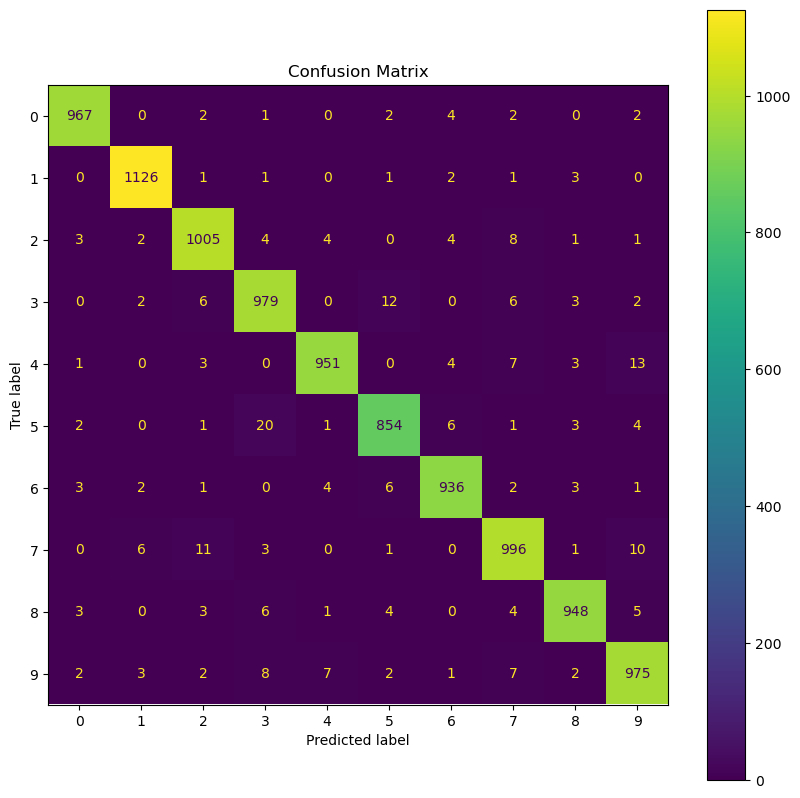

In [10]:
from sklearn import metrics

# Creating list for labels and predictions.
labs_list = []
prds_list = []

# Evaluating the performance of the trained model on the test set.
with torch.no_grad():  # No need for computing gradients during test.

    # Iterating over test batches.
    for data in tstloader:

        # Recovering inputs and labels from test batch.
        imgs, labs = data

        # Casting tensors to GPU.
        imgs = imgs.to(device)  # imgs.shape -> (B, Ch, H, W)
        labs = labs.to(device)  # labs.shape -> (B)

        # Forward pass of inputs through the network. + backward + optimize
        outs = net(imgs)  # outs.shape -> (B, K)

        # Computing index with max activations in dimension 1 (classes).
        prds = torch.argmax(outs, 1)  # prds.shape -> (B)

        # Appending lists with labels and predictions from the current batch.
        labs_list.extend(labs.tolist())
        prds_list.extend(prds.tolist())

# Computing test set metrics.
acc = metrics.accuracy_score(labs_list, prds_list)
cnf = metrics.confusion_matrix(labs_list, prds_list)
print('Accuracy %.4f' % (acc))

# Plotting confusion matrix.
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cnf,
                                       display_labels=[str(i) for i in range(n_classes)])
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
disp.plot(ax=ax)
ax.set_title('Confusion Matrix')
plt.show()